In [1]:
import pandas as pd 
import numpy as np

np.random.seed(42)
n=1000
df=pd.DataFrame({
    "customer_age":np.random.randint(18,75,n),
    "annual_income":np.concatenate([np.random.normal(60000,15000,950),np.random.normal(250000,30000,50)]),
    "purchase_amount":np.random.exponential(80,n),
    "product_category":np.random.choice(["Electronics","Clothing","Food","Books","Sports"],n),
    "size":np.random.choice(["S","M","L","XL"],n,p=[0.2,0.35,0.3,0.15]),"region":np.random.choice(["North","South","East","West"],n),
    "is_returned":np.random.binomial(1,0.15,n)})


df.to_csv("day01_retail.csv",index=False)

In [2]:


df = pd.read_csv("day01_retail.csv")


df.head()


,customer_age,annual_income,purchase_amount,product_category,size,region,is_returned
0,56,28988.368499,15.625616,Sports,L,North,0
1,69,58663.199407,63.001362,Books,XL,West,0
2,46,40432.957492,334.234128,Sports,M,West,0
3,32,70045.088232,221.663951,Food,M,South,0
4,60,65498.973691,3.530676,Food,L,West,0


In [3]:
df.shape

(1000, 7)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customer_age      1000 non-null   int64  
 1   annual_income     1000 non-null   float64
 2   purchase_amount   1000 non-null   float64
 3   product_category  1000 non-null   str    
 4   size              1000 non-null   str    
 5   region            1000 non-null   str    
 6   is_returned       1000 non-null   int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 54.8 KB


In [5]:
df.describe(include="all")


,customer_age,annual_income,purchase_amount,product_category,size,region,is_returned
count,1000.000000,1000.000000,1000.000000,1000,1000,1000,1000.000000
unique,NaN,NaN,NaN,5,4,4,NaN
top,NaN,NaN,NaN,Food,M,South,NaN
freq,NaN,NaN,NaN,213,347,286,NaN
mean,46.247000,70399.469172,79.124265,NaN,NaN,NaN,0.154000
std,16.288072,45771.526816,78.721177,NaN,NaN,NaN,0.361129
min,18.000000,16556.169327,0.010776,NaN,NaN,NaN,0.000000
25%,33.000000,51234.612502,23.912122,NaN,NaN,NaN,0.000000
50%,46.000000,61266.553326,54.906167,NaN,NaN,NaN,0.000000
75%,60.250000,72467.011542,110.716995,NaN,NaN,NaN,0.000000


In [6]:
columns = df.columns

In [7]:
display(df['size'].value_counts(normalize=True))
display(df['product_category'].value_counts())

size
M     0.347
L     0.292
S     0.224
XL    0.137
Name: proportion, dtype: float64

product_category
Food           213
Sports         209
Electronics    208
Books          185
Clothing       185
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Annual Income')

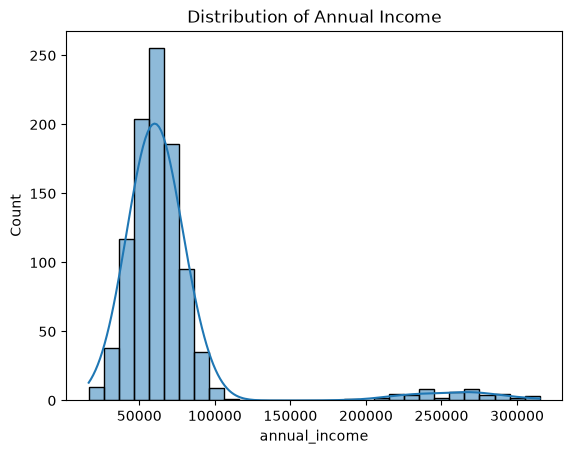

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["annual_income"], bins=30, kde=True)
plt.title("Distribution of Annual Income")

Text(0.5, 1.0, 'Average Purchase Amount by Product Category')

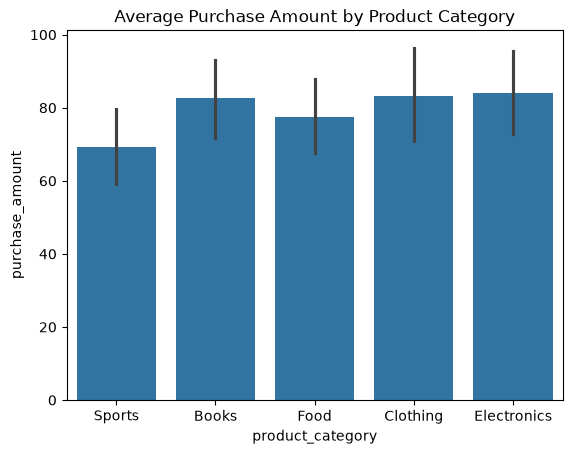

In [9]:
sns.barplot(x='product_category', y='purchase_amount', data=df)
plt.title("Average Purchase Amount by Product Category")

<Axes: ylabel='product_category'>

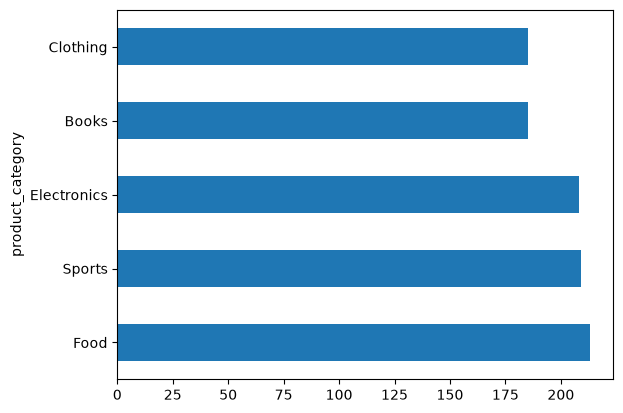

In [10]:
df['product_category'].value_counts().plot(kind='barh')

In [11]:
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


In [12]:
columns

Index(['customer_age', 'annual_income', 'purchase_amount', 'product_category',
       'size', 'region', 'is_returned'],
      dtype='str')

In [13]:
from sklearn.preprocessing import OrdinalEncoder

size_order = [["S","M","L","XL"]]
ordinal = OrdinalEncoder(categories=size_order)

encoded_size_order = ordinal.fit_transform(df[["size"]])

display(encoded_size_order[:10])
display(encoded_size_order[:10].ravel())

array([[2.],
       [3.],
       [1.],
       [1.],
       [2.],
       [1.],
       [0.],
       [1.],
       [1.],
       [1.]])

array([2., 3., 1., 1., 2., 1., 0., 1., 1., 1.])

In [14]:
from sklearn.preprocessing import OneHotEncoder

onehot = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded_onehot = onehot.fit_transform(df[['product_category']])

display("new column names:", onehot.get_feature_names_out(['product_category']))
display(df['product_category'].value_counts())
display(encoded_onehot[:10])

'new column names:'

array(['product_category_Books', 'product_category_Clothing',
       'product_category_Electronics', 'product_category_Food',
       'product_category_Sports'], dtype=object)

product_category
Food           213
Sports         209
Electronics    208
Books          185
Clothing       185
Name: count, dtype: int64

array([[0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0.]])

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df['is_returned'])

display("Encoded labels:", y[:10])
display("classes:", le.classes_)

'Encoded labels:'

array([0, 0, 0, 0, 0, 0, 0, 1, 1, 0])

'classes:'

array([0, 1])

**REFLECTION** : if we added a category "XXL" in the dataset without updating the already curated list, it will probably fail. We listed down the categories so it will understand the order or hierarchy of the feature.  Although im not sure what error it will occur, im 100% sure it will fail.  As for One hot encoder with handle_unknown='ignore' parameter, it will still proceed by ignoring new valuies that is not listed up with the initial setup. 

**Edit** : After some research on ordinal order topic, `ValueError` will occur

## TRAIN TEST SPLIT

In [16]:
from sklearn.model_selection import train_test_split


target = 'is_returned'

X = df.drop(columns=[target])
y = df[target]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train mean (proportion returned):", round(y_train.mean(), 4))
print("y_test mean (proportion returned):", round(y_test.mean(), 4))

X_train shape: (800, 6)
X_test shape: (200, 6)
y_train mean (proportion returned): 0.1538
y_test mean (proportion returned): 0.155


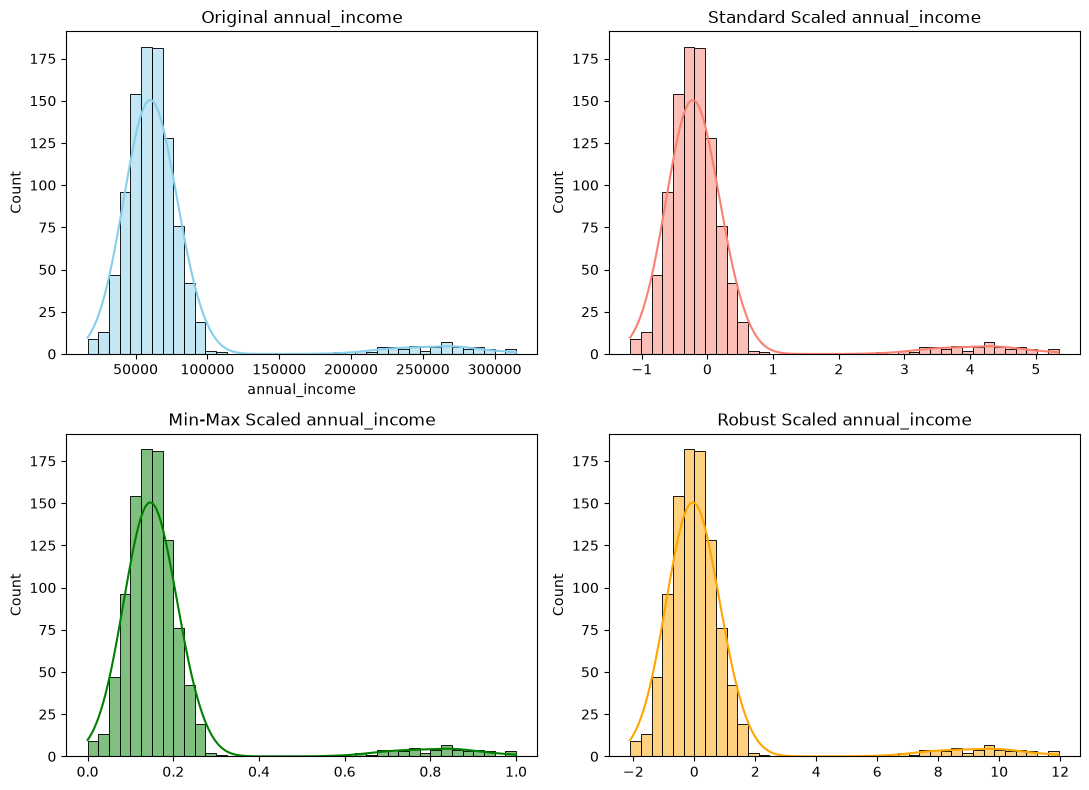

StandardScaler range: -1.18 to 5.35
MinMaxScaler range: 0.0 to 1.0
RobustScaler range: -2.11 to 11.95


In [17]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler


income = df[["annual_income"]]

std_scaler = StandardScaler().fit_transform(income)
minmax_scaler = MinMaxScaler().fit_transform(income)
robust_scaler = RobustScaler().fit_transform(income)


fig, axes = plt.subplots(2,2, figsize=(11, 8))

# Original distribution
sns.histplot(income['annual_income'], bins=40, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Original annual_income')

# Standard Scaler
sns.histplot(std_scaler.ravel(), bins=40, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Standard Scaled annual_income')

# Min Max Scaler
sns.histplot(minmax_scaler.ravel(), bins=40, kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Min-Max Scaled annual_income')

# Robust Scaler
sns.histplot(robust_scaler.ravel(), bins=40, kde=True, ax=axes[1,1], color='orange')
axes[1,1].set_title('Robust Scaled annual_income')

plt.tight_layout()
plt.savefig("scaling_comparison.png")
plt.show()

print("StandardScaler range:", std_scaler.min().round(2), "to", std_scaler.max().round(2))
print("MinMaxScaler range:", minmax_scaler.min().round(2), "to", minmax_scaler.max().round(2))
print("RobustScaler range:", robust_scaler.min().round(2), "to", robust_scaler.max().round(2))

<Axes: xlabel='customer_age', ylabel='Count'>

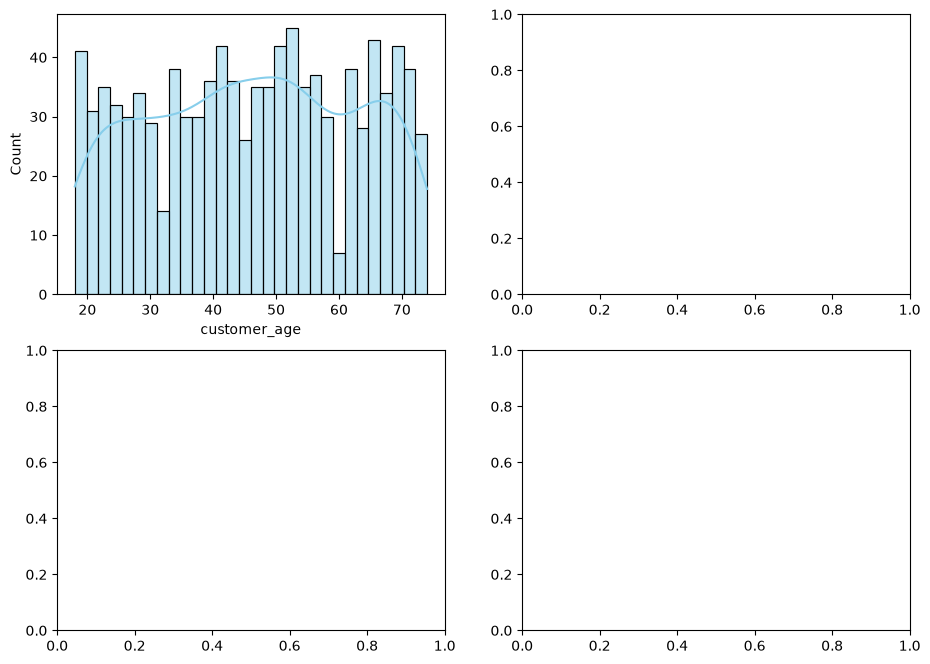

In [ ]:

age = df[["customer_age"]]

age_std_scaled = StandardScaler().fit_transform(age)
age_minmax_scaled = MinMaxScaler().fit_transform(age)
age_robust_scaled = RobustScaler().fit_transform(age)

fig, axes = plt.subplots(2,2, figsize=(11, 8))
# original distribution
sns.histplot(age['customer_age'], bins=30, kde=True, ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Original customer_age')

# Standard Scaler
sns.histplot(age_std_scaled.ravel(), bins=30, kde=True, ax=axes[0,1], color='salmon')
axes[0,1].set_title('Standard Scaled customer_age')

# Min Max Scaler
sns.histplot(age_minmax_scaled.ravel(), bins=30, kde=True, ax=axes[1,0], color='green')
axes[1,0].set_title('Min-Max Scaled customer_age')

# Robust Scaler
sns.histplot(age_robust_scaled.ravel(), bins=30, kde=True, ax=axes[1,1], color='orange')
axes[1,1].set_title('Robust Scaled customer_age')
plt.tight_layout()
plt.savefig("age_scaling_comparison.png")
plt.show()